In [1]:
from mlipkit.mattersim.mattersim_model import MatterSimModel
#MatterSimModel.load_doc('hyperparameters')
import numpy as np

from ase.io import read
from mlipkit.MTP.mtp_model import MTPModel
from mlipkit.utils import find_min_dist

root_dir = './'
name = 'mattersim_trial_model' # custom name

train_set = read('../../../../../sets/Si/TrainSet.traj', index=':')

hyperparameters = dict(device='cpu',
                       run_name = 'run0',
                       finetune_script_path = '/Users/samuel/Work/codes/python_packages/mattersim/src/mattersim/training/finetune_mattersim.py',
                       load_model_path = '/Users/samuel/Work/codes/python_packages/mattersim/pretrained_models/mattersim-v1.0.0-5M.pth',
                       cutoff = 2,
                       epochs = 2,
                       save_checkpoint = True,
                       ckpt_interval=1)

new_model = MatterSimModel(root_dir,
                      name=name,
                      hyperparameters=hyperparameters,
                      train_set=train_set)


new_model.train_model()

ncores:  1
Command for the training: torchrun --nproc_per_node=1 /Users/samuel/Work/codes/python_packages/mattersim/src/mattersim/training/finetune_mattersim.py  --run_name run0 --load_model_path /Users/samuel/Work/codes/python_packages/mattersim/pretrained_models/mattersim-v1.0.0-5M.pth --save_checkpoint --ckpt_interval 1 --device cpu --cutoff 2 --threebody_cutoff 4 --epochs 2 --batch_size 16 --lr 0.0002 --step_size 10 --include_forces --include_stresses --force_loss_ratio 1 --stress_loss_ratio 0.1 --early_stop_patience 10 --seed 42 --scale_key per_species_forces_rms --shift_key per_species_energy_mean_linear_reg --wandb_project wandb_test --save_path training_results --train_data_path /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/mattersim/Tutorial_1/training/Training_set.traj --valid_data_path /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/mattersim/Tutorial_1/training/Test_set.traj
Training done successfully


### 3. Compute properties of a structure with the model
The training ran succesfully. Let's check if it's trained with
```python
new_model.is_trained
```

Note that the model was saved ad json in the root directory, and the trained potential is saved inside ```root_dir/trained_pot/```. Check
```pyhton
new_model.trained_pot_filepaths
```

Now let's use the trained potential to compute the properties of a structure.
But first let's have a look at the parameters needed:
```python
MTP_model.load_doc('parameters_compute_properties')
```


In [2]:
MatterSimModel.load_doc('parameters_compute_properties')

device: Device to run inference on ('cpu' or 'cuda'). GPU is highly recommended for deep learning models.



In [2]:

structures = read('../../../../../sets/Si/TestSet.traj', index=':4') # note this is a list
parameters = {'device':'cpu'}
true_energy = structures[3].get_total_energy()

results = new_model.compute_properties(structures, wdir='prediction', parameters=parameters)

# Let's print the energy
true_energy = structures[3].get_total_energy()
ml_energy = results[3].get_total_energy()

print(f'True energy: {true_energy} eV/atom;\nML energy: {ml_energy} eV/atom;\nError: {true_energy - ml_energy: .5e} eV/atom')

2026-04-07 23:54:56.587 | INFO     | mattersim.forcefield.potential:from_checkpoint:893 - Loading the model from /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/mattersim/Tutorial_1/trained_pot/pot.pth
True energy: -24784.542004358165 eV/atom;
ML energy: -514.0383745877922 eV/atom;
Error: -2.42705e+04 eV/atom


### 4. Have a look at the hash-based security system
When a model is trained (successfully), two hashes are generated for the training set and the trained potential files. The hashes are stored in metadata and in the object itself. This allows to ensure, when opening a saved trained MlipModel object, that the training set is the one used for the training. It is always possible to ignore the metadata.

Let's load the model. Then we'll manually change the metadata and try to load the saved object again. 

In [3]:
from mlipkit.mlip_models import MlipModel

In [6]:
# First load the model
loaded_model = MlipModel.load_model(path ='mattersim_trial_model.json', train_set=train_set)

# Let's try to compute some properties
results = loaded_model.compute_properties(structures, wdir='prediction', parameters=parameters)
print(f'ML energy: {results[3].get_total_energy()} eV/atom')

2026-04-07 23:56:34.227 | INFO     | mattersim.forcefield.potential:from_checkpoint:893 - Loading the model from /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/mattersim/Tutorial_1/trained_pot/pot.pth
ML energy: -514.0383745877922 eV/atom


Now let's modify the hashes and reload

In [8]:
# Reload
loaded_model = MlipModel.load_model(path ='./mattersim_trial_model.json')#, train_set=train_set)

# Let's try to compute some properties
results = loaded_model.compute_properties(structures, wdir='prediction', parameters=parameters)
print(f'ML energy: {results[0].get_total_energy()} eV/atom')

2026-04-07 23:57:34.973 | INFO     | mattersim.forcefield.potential:from_checkpoint:893 - Loading the model from /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/mattersim/Tutorial_1/trained_pot/pot.pth
ML energy: -556.6876022813699 eV/atom


### 5. Load a pre-trained MTP model
In case we already had a trained model, we can load it as an MlipModel (sub)class, provided that we have all the files needed to define a trained potential of its class. Let's use ```MTP_model.load_doc('trained_pot_files')``` to see what these files are. Then we'll build a dictionary with the paths.

In [9]:
MatterSimModel.load_doc('trained_pot_files')

potential_file: pot.pth - The PyTorch state dictionary containing the fine-tuned weights.



In [13]:
files = {'potential_file' : 'trained_pot/pot.pth'}
pre_trained_model = MatterSimModel(root_dir='pre_trained_model', 
                              name='pre_trained', 
                              pre_trained=True, 
                              pre_trained_pot_filepaths=files)

Let's use it to compute some properties

In [14]:
results = pre_trained_model.compute_properties(structures, wdir='prediction', parameters=parameters)
true_energy = structures[3].get_total_energy()
ml_energy = results[3].get_total_energy()
print(f'True energy: {true_energy} eV/atom;\nML energy: {ml_energy} eV/atom;\nError: {true_energy - ml_energy: .5e} eV/atom')

2026-04-08 00:00:27.272 | INFO     | mattersim.forcefield.potential:from_checkpoint:893 - Loading the model from /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/mattersim/Tutorial_1/trained_pot/pot.pth
True energy: -24784.542004358165 eV/atom;
ML energy: -514.0383745877922 eV/atom;
Error: -2.42705e+04 eV/atom


### 6. Evaluate the model on the training set and test set
Now let's compute error metrics for the pre-trained model on the datasets. 

In [16]:
# Load the test set
test_set = read('../../../../../sets/Si/TestSet.traj', index=':')

# Evaluate on training set
res_train_set, errs_train = pre_trained_model.evaluate_on_dataset(dataset=train_set, wdir='evaluation-train', parameters=parameters, save_results=True)

# Evaluate on test set
res_test_set, errs_test = pre_trained_model.evaluate_on_dataset(dataset=test_set, wdir='evaluation-test', parameters=parameters, save_results=True)

printing in /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/MTP/Tutorial_1/evaluation-train/Energy_comparison.dat
printing in /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/MTP/Tutorial_1/evaluation-train/Forces_comparison.dat
printing in /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/MTP/Tutorial_1/evaluation-train/Stress_comparison.dat
printing in /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/MTP/Tutorial_1/evaluation-test/Energy_comparison.dat
printing in /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/MTP/Tutorial_1/evaluation-test/Forces_comparison.dat
printing in /Users/samuel/Work/codes/python_packages/mlipkit/mlipkit/tutorial/MTP/Tutorial_1/evaluation-test/Stress_comparison.dat


Text(-5.47015575272185, 3.1770931870522103, 'rmse: 3.36541e-04 eV/Ang\nmae: 2.52966e-04 eV/Ang\nR2: 9.99977e-01')

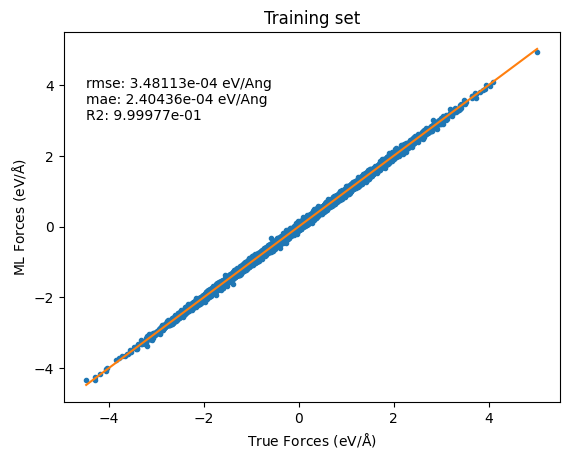

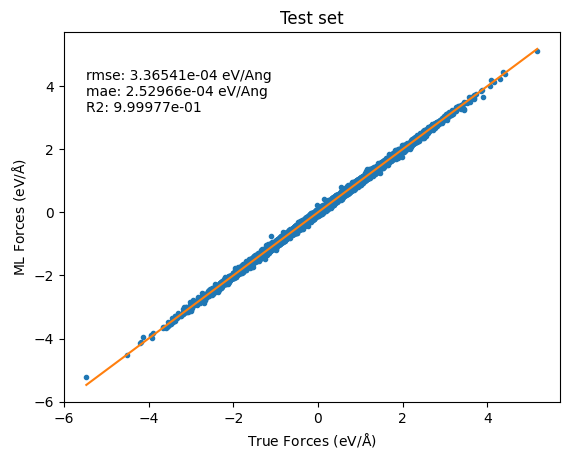

In [17]:
# Let's plot the comparisons
from matplotlib import pyplot as plt

# For training set
true_forces = np.array([x.get_forces() for x in train_set]).flatten()
ml_forces = np.array([x.get_forces() for x in res_train_set]).flatten()

plt.plot(true_forces, ml_forces, '.')
plt.xlabel('True Forces (eV/$\mathrm{\AA}$)')
plt.ylabel('ML Forces (eV/$\mathrm{\AA}$)')
plt.plot([min(true_forces), max(true_forces)], [min(true_forces), max(true_forces)])
plt.title('Training set')
plt.text(x=min(true_forces), y=max(true_forces)-2, s=f"rmse: {errs_train['energy'][0]:.5e} eV/Ang\nmae: {errs_train['energy'][1]:.5e} eV/Ang\nR2: {errs_train['energy'][2]:.5e}")

# For test set
true_forces = np.array([x.get_forces() for x in test_set]).flatten()
ml_forces = np.array([x.get_forces() for x in res_test_set]).flatten()

plt.figure()
plt.plot(true_forces, ml_forces, '.')
plt.xlabel('True Forces (eV/$\mathrm{\AA}$)')
plt.ylabel('ML Forces (eV/$\mathrm{\AA}$)')
plt.plot([min(true_forces), max(true_forces)], [min(true_forces), max(true_forces)])
plt.title('Test set')
plt.text(x=min(true_forces), y=max(true_forces)-2, s=f"rmse: {errs_test['energy'][0]:.5e} eV/Ang\nmae: {errs_test['energy'][1]:.5e} eV/Ang\nR2: {errs_test['energy'][2]:.5e}")


